<h1 style="text-align:center;">Ito Calculus<br></h1>
<div style="text-align:center;">Ariel Kalingking </div>
<div style="text-align:center;">akalingking@gmail.com </div>
<div style="text-align:center;">Appendix: Python Code </div>

In [7]:
import math
import numpy as np
import statsmodels.api as sm
import logging
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

plt_inline_enable = False # Turn this off when running makefile
imagepath = "../paper/figures/"
figsize = (4,3)
fontbig = 8
fontmed = 7
fontsmall = 6

matplotlib.use('TkAgg')
logging.getLogger().setLevel(logging.ERROR)
if plt_inline_enable:
    %matplotlib inline

In [8]:
np.random.seed(18)
T = 1.0       # Time horizon, 1 year
N = 252       # Number of steps, trading days
dt = T/N      # Time step
mu = 1.0      # Drift coefficient for X_t
sigma = 0.5   # Diffusion coefficient for X_t 

# Initialize X_t
X_0 = 0.0
X_T = 0.0
X = np.zeros(N)
dW = np.zeros(N)
time = np.linspace(0, T, N)
int_sum_t = np.zeros(N) # approximation using integral sum

# Set initial value
X[0] = X_0
for i in range(N-1):
    # Generate the Brownian step
    dW[i] = np.sqrt(dt) * np.random.randn()
    # Simulate X_t path using Euler-Maruyama (which is exact here)
    X[i+1] = X[i] + mu * dt + sigma * dW[i]
    # The Itô integral is defined as the limit of sum(X_t_k * dW_k).
    # Let's calculate this sum directly for comparison with theoretical Ito integral below.
    int_sum_t[i+1] = int_sum_t[i] + X[i] * dW[i]
    
# Extract final value, X_T
X_T = X[-1]

# Analytical Calculation
# Calculate the value of the Itô integral using:
# I_ito = X_T^2 - X_0^2 - 2 * integral(X_t dt) - 0.25 * T
int_ito_exact = X_T**2 - X_0**2 - (2 * np.sum(X*dt)) - (0.25 * T)

# The Itô integral is defined as the limit of sum(X_t_k * dW_k).
# Let's calculate this sum directly for comparison.
# The sum: sum_{k=0}^{n-1} X_{t_k} * Delta W_k
int_sum = np.sum(X * dW)
error = abs(int_ito_exact - int_sum_t[-1])/int_ito_exact

#print(f"Ito integral analytical: {int_ito_exact:.3f}")
#print(f"Integral by summation:    {int_sum_t[-1]:.3f}")
#print(f"Approximation error: {error*100:.3f}%")

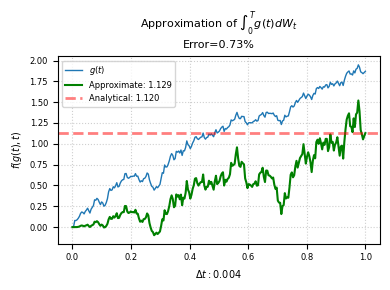

In [9]:
fig =  plt.figure(figsize=figsize)
ax = fig.add_subplot(111)
ax.plot(time, X, label=r"$g(t)$", linewidth=1)
ax.plot(time, int_sum_t, color="green", label=f"Approximate: {int_sum_t[-1]:.3f}")
ax.axhline(int_sum, color="red", linestyle="--", linewidth=2.0, alpha=0.5,
           label=f"Analytical: {int_ito_exact:.3f}")
ax.set_title(f'Approximation of $\int_0^T g(t) dW_t$\nError={error*100:.2f}%',
             fontsize=fontbig, fontweight="normal")
ax.set_xlabel(f'$\Delta t: {dt:.3f}$', fontsize=fontmed)
ax.set_ylabel('$f(g(t), t)$', fontsize=fontmed)
ax.tick_params(axis='both', which='major', labelsize=fontsmall) 
ax.legend(loc="best",fontsize=fontsmall)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig(imagepath+"ito_integral_2.pdf", bbox_inches="tight")
if plt_inline_enable:
    plt.show()